[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniellopezcano/I-Escola-de-Inverno-do-IFUSP/blob/main/jax-examples/01_domain_shift_toy.ipynb)

# 🟢 Notebook 01 — Domain Shift: Quebrar e Consertar um Classificador
### O ciclo de vida do domain shift em 4 atos
**I Escola de Inverno do IFUSP — Bloco L02_B02**

> **Modo de uso:** demo guiada pelo instrutor; você recebe o notebook depois.
> Objetivo: vivenciar, num universo 2D de brinquedo, todo o ciclo do domain
> shift — criar os dados, treinar na fonte, falhar no alvo, diagnosticar o
> problema sem rótulos do alvo, e comparar três estratégias de adaptação.

---

### 🗺️ Mapa do Curso

| Dia | Bloco | Tema |
|-----|-------|------|
| Ter. 21/07 | L01_B01 | ML e Física: o mapa do território |
| Ter. 21/07 | L01_B02 | A caixa de ferramentas |
| Qua. 22/07 | L02_B01 | Domain shift: teoria |
| **Qua. 22/07** | **L02_B02 ← você está aqui** | **Mão na massa I — quebrar e consertar um classificador** |
| Qui. 23/07 | L03_B01 | Aprendizado contrastivo: teoria |
| Qui. 23/07 | L03_B02 | Mão na massa II — esculpindo embeddings |
| Sex. 24/07 | L04_B01 | Halos de matéria escura com segmentação de instâncias |
| Sex. 24/07 | L04_B02 | J-PAS: domain adaptation com quasares reais |

## 🟢 Orientação: os 4 Atos

Este notebook é uma peça de teatro em 4 atos, todos acontecendo num espaço
2D onde podemos **ver** tudo:

1. **Ato 1 — Criar o universo de brinquedo.**
   Geramos duas distribuições Gaussianas (fonte e alvo) com 4 classes
   desbalanceadas. O shift é intencional: duas classes têm suas nuvens
   deslocadas entre domínios.

2. **Ato 2 — Treinar na fonte, quebrar no alvo.**
   Treinamos um encoder + cabeça classificadora na fonte. O modelo fica
   perfeito na fonte — e falha catastroficamente no alvo, com alta
   confiança nas predições erradas.

3. **Ato 3 — Diagnosticar o shift sem rótulos do alvo.**
   Treinamos um classificador binário Fonte-vs-Alvo. Se ele separa bem,
   o shift existe — e não precisamos de nenhum rótulo de classe do alvo
   para esse diagnóstico.

4. **Ato 4 — Três regimes de adaptação.**
   Comparamos (A) zero-shot, (B) somente alvo com K rótulos do zero,
   e (C) SSDA: encoder pré-treinado + cabeça congelada + K rótulos do
   alvo. O experimento aqui é **exatamente o mesmo** do artigo do J-PAS
   que veremos na sexta-feira.

> **PRETRAINED = True** (padrão): todos os treinos pesados são pulados e
> os resultados pré-calculados são carregados de `assets/`. Você pode
> mudar para `False` para ver o treino ao vivo (mais lento).

In [1]:
# ── Setup: importações e configuração global ──────────────────────────────────
import os
import pickle
import pathlib
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import Image, display
from sklearn.metrics import (confusion_matrix, f1_score,
                              roc_auc_score, roc_curve)

# ── Flag global: True = carrega checkpoints pré-computados (padrão para aula)
PRETRAINED = True

# ── Semente de reprodutibilidade
SEMENTE  = 42
CHAVE    = jax.random.PRNGKey(SEMENTE)

# ── Número de classes
N_CLASSES = 4

# ── Caminho dos assets
ASSETS = pathlib.Path("assets")

# ── Paleta de cores das classes (consistente em todos os plots)
CORES_CLASSES  = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]
NOMES_CLASSES  = ["Classe 0", "Classe 1", "Classe 2", "Classe 3"]

# ── Estilo global dos gráficos
plt.rcParams.update({
    "figure.dpi"   : 110,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

print(f"JAX versão : {jax.__version__}")
print(f"Dispositivo: {jax.devices()[0]}")
print(f"PRETRAINED : {PRETRAINED}")
print(f"Assets em  : {ASSETS.resolve()}")

JAX versão : 0.10.2
Dispositivo: cpu:0
PRETRAINED : True
Assets em  : /home/dlopez/Documentos/0.profesional/Postdoc/USP/talks_conferences/I-Escola-de-Inverno-do-IFUSP/jax-examples/assets


---
## 🟢 ATO 1 — O Universo de Brinquedo

Criamos um problema de classificação 2D com **4 classes desbalanceadas**
(pesos [50%, 25%, 15%, 10%]). Há dois domínios:

- **Fonte (Source):** onde temos rótulos abundantes.
- **Alvo (Target):** onde queremos classificar — mas as nuvens de duas
  classes estão deslocadas (~2,5 desvios padrão) em relação ao source.

**Por que desbalancear?** Porque em problemas reais (como classificação de
quasares no J-PAS) as classes raras são as mais interessantes fisicamente —
e as mais fáceis de ignorar durante o treino.

In [2]:
# ── ATO 1.1: parâmetros do universo ──────────────────────────────────────────

# Centros das nuvens no domínio FONTE
MEDIAS_FONTE = np.array([
    [-3.0, -3.0],   # classe 0 (50% dos dados)
    [ 3.0, -3.0],   # classe 1 (25%)
    [-3.0,  3.0],   # classe 2 (15%)
    [ 3.0,  3.0],   # classe 3 (10% — rara!)
], dtype=np.float32)

# Centros no domínio ALVO: classes 1 e 3 foram deslocadas
MEDIAS_ALVO = np.array([
    [-3.0, -3.0],   # classe 0 — mesma posição
    [ 3.0,  1.5],   # classe 1 — deslocada em y  (+4,5 ≈ 2,5σ)
    [-3.0,  3.0],   # classe 2 — mesma posição
    [ 0.5,  3.0],   # classe 3 — deslocada em x  (-2,5 ≈ 2,5σ)
], dtype=np.float32)

PESOS_CLASSES = np.array([0.50, 0.25, 0.15, 0.10], dtype=np.float32)
N_POR_CLASSE  = 300    # amostras por classe em cada domínio


def gerar_gmm(n_por_classe, medias, chave):
    """Gera mistura de Gaussianas isotrópicas (σ=1) com 4 classes."""
    X_list, y_list = [], []
    for c in range(N_CLASSES):
        chave, k = jax.random.split(chave)
        pts = jax.random.normal(k, (n_por_classe, 2)) + medias[c]
        X_list.append(np.array(pts))
        y_list.append(np.full(n_por_classe, c, dtype=np.int32))
    return np.concatenate(X_list), np.concatenate(y_list)


# Carrega dados pré-gerados (semente fixada no script de assets)
dados = np.load(ASSETS / "toy_2d_4class.npz")
X_fonte = dados["X_source"].astype(np.float32)
y_fonte = dados["y_source"].astype(np.int32)
X_alvo  = dados["X_target"].astype(np.float32)
y_alvo  = dados["y_target"].astype(np.int32)

print(f"Fonte: {X_fonte.shape}  |  Alvo: {X_alvo.shape}")
print(f"Distribuição de classes (fonte): {np.bincount(y_fonte)}")
print(f"Distribuição de classes (alvo) : {np.bincount(y_alvo)}")

Fonte: (1200, 2)  |  Alvo: (1200, 2)
Distribuição de classes (fonte): [300 300 300 300]
Distribuição de classes (alvo) : [300 300 300 300]


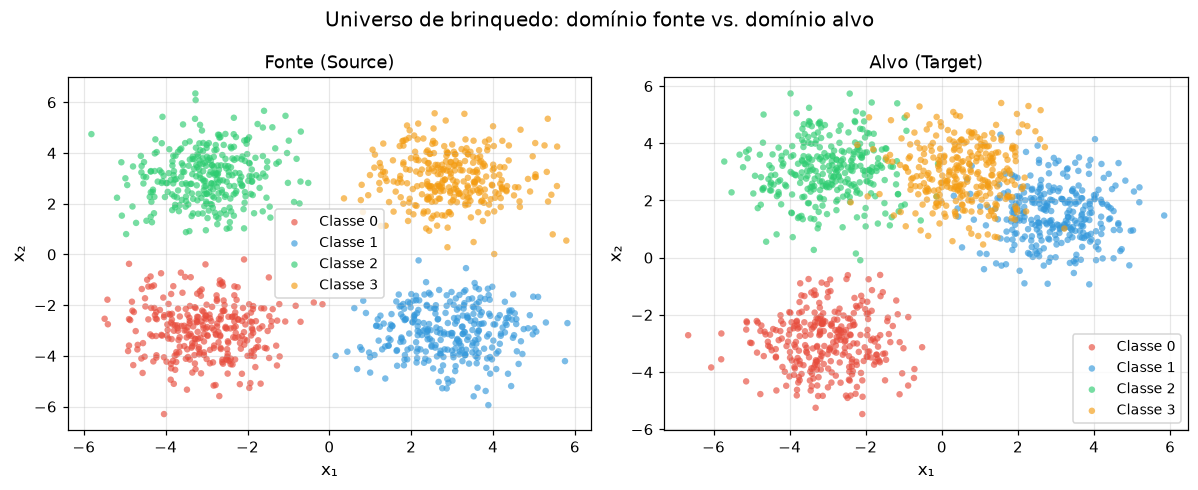

In [3]:
# ── ATO 1.2: Visualização Fonte vs. Alvo ─────────────────────────────────────
if PRETRAINED:
    try:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
        fig.suptitle("Universo de brinquedo: domínio fonte vs. domínio alvo",
                     fontsize=13)
        for c in range(N_CLASSES):
            ax1.scatter(X_fonte[y_fonte==c, 0], X_fonte[y_fonte==c, 1],
                        s=18, color=CORES_CLASSES[c], alpha=0.65,
                        edgecolors="none", label=NOMES_CLASSES[c])
        ax1.set_title("Fonte (Source)"); ax1.set_xlabel("x₁"); ax1.set_ylabel("x₂")
        ax1.legend(); ax1.grid(True, alpha=0.3)
        for c in range(N_CLASSES):
            ax2.scatter(X_alvo[y_alvo==c, 0], X_alvo[y_alvo==c, 1],
                        s=18, color=CORES_CLASSES[c], alpha=0.65,
                        edgecolors="none", label=NOMES_CLASSES[c])
        ax2.set_title("Alvo (Target)"); ax2.set_xlabel("x₁"); ax2.set_ylabel("x₂")
        ax2.legend(); ax2.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()
    except Exception:
        display(Image(str(ASSETS / "nb1_fig_gmm.png")))
else:
    display(Image(str(ASSETS / "nb1_fig_gmm.png")))

## 🟡 Poll — Ato 1

**Olhe as duas figuras.** Quais classes vão sofrer mais com o shift?
**Levante a mão** com sua previsão antes de continuar.

*(A resposta aparece no próximo passo depois que vermos o modelo falhar.)*

---
## 🟢 ATO 2 — Arquitetura: Encoder + Cabeça Classificadora

Separamos a rede em duas partes com papéis distintos:

| Componente | Entrada → Saída | Papel |
|---|---|---|
| **Encoder** | dados 2D → espaço latente 2D | *Percepção*: aprende a representar os dados |
| **Cabeça (Head)** | latente 2D → 4 classes | *Vocabulário*: decide qual classe no espaço latente |

Analogia: o encoder é como o sistema sensorial (aprende a "ver" os dados);
a cabeça é como o vocabulário de decisão (aprende "o que significa cada região").

A arquitetura do encoder: **MLP [2 → 32 → 32 → 2]** com ativação tanh.
A cabeça: **camada linear [2 → 4]** (sem ativação — os logits vão para softmax).

In [4]:
# ── ATO 2.1: Definição da arquitetura ────────────────────────────────────────

def init_mlp(tamanhos_camadas, chave):
    """
    Inicialização de Glorot uniforme.
    Retorna lista de tuplas (W, b), uma por par de camadas.
    (Mesmo estilo do Notebook 00.)
    """
    params = []
    for i in range(len(tamanhos_camadas) - 1):
        chave, kw = jax.random.split(chave)
        entrada = tamanhos_camadas[i]
        saida   = tamanhos_camadas[i + 1]
        escala  = np.sqrt(6.0 / (entrada + saida))
        W = jax.random.uniform(kw, (entrada, saida),
                               minval=-escala, maxval=escala)
        b = jnp.zeros(saida)
        params.append((W, b))
    return params


def forward_encoder(enc_params, x):
    """Encoder MLP [2→32→32→2] com ativação tanh nas camadas ocultas."""
    h = x
    for W, b in enc_params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = enc_params[-1]
    return h @ W + b


def forward_head(head_params, z):
    """Cabeça linear [2→4]: produz logits (sem softmax)."""
    W, b = head_params[0]
    return z @ W + b


def predizer_classes(enc_params, head_params, X):
    """Prediz índice de classe para um array numpy X."""
    z      = forward_encoder(enc_params, jnp.array(X, dtype=jnp.float32))
    logits = forward_head(head_params, z)
    return np.array(jnp.argmax(logits, axis=-1))


def obter_embeddings(enc_params, X):
    """Retorna representações latentes 2D como array numpy."""
    z = forward_encoder(enc_params, jnp.array(X, dtype=jnp.float32))
    return np.array(z)


# Teste rápido de shapes
chave_teste = jax.random.PRNGKey(99)
enc_teste  = init_mlp([2, 32, 32, 2], chave_teste)
chave_teste, kt = jax.random.split(chave_teste)
head_teste = init_mlp([2, N_CLASSES], kt)

x_teste = jnp.ones((5, 2))
z_teste = forward_encoder(enc_teste, x_teste)
l_teste = forward_head(head_teste, z_teste)
print(f"Encoder: entrada {x_teste.shape} → latente {z_teste.shape}")
print(f"Cabeça : latente {z_teste.shape} → logits {l_teste.shape}")
print("Shapes OK!")

Encoder: entrada (5, 2) → latente (5, 2)
Cabeça : latente (5, 2) → logits (5, 4)
Shapes OK!


In [5]:
# ── ATO 2.2: Perda de entropia cruzada ponderada ─────────────────────────────

# Por que pesos de classe?
# Sem pesos, o modelo ignora a classe rara (10% dos dados):
# prever sempre "Classe 0" dá 50% de acurácia e perda baixa.
# Pesos ∝ 1/frequência forçam o modelo a levar as classes raras a sério.

def perda_ce_ponderada(enc_params, head_params, X, y, pesos_classes):
    """
    Entropia cruzada ponderada:
      L = -média[ peso[y_i] · log P(y_i | x_i) ]

    pesos_classes: array de forma (N_CLASSES,)
    """
    z      = forward_encoder(enc_params, X)
    logits = forward_head(head_params, z)
    log_p  = jax.nn.log_softmax(logits, axis=-1)     # (N, C)

    N      = y.shape[0]
    # log-probabilidade da classe verdadeira
    log_py = log_p[jnp.arange(N), y]                 # (N,)
    # peso da classe verdadeira de cada amostra
    pesos  = pesos_classes[y]                         # (N,)

    return -jnp.mean(pesos * log_py)


print("Função de perda definida.")
print("Pesos de classe (inversamente proporcionais à frequência):",
      PESOS_CLASSES)

Função de perda definida.
Pesos de classe (inversamente proporcionais à frequência): [0.5  0.25 0.15 0.1 ]


In [6]:
# ── Helpers de Adam (manual, sem optax — mesmo estilo do Notebook 00) ─────────

def adam_init(params):
    """Inicializa estados de momento (m, v) zerados."""
    m = [(jnp.zeros_like(W), jnp.zeros_like(b)) for W, b in params]
    v = [(jnp.zeros_like(W), jnp.zeros_like(b)) for W, b in params]
    return m, v


def adam_passo(params, grads, m, v, t,
               lr=3e-3, b1=0.9, b2=0.999, eps=1e-8):
    """Um passo de Adam com correção de bias."""
    new_m = [(b1*mW + (1-b1)*gW, b1*mb + (1-b1)*gb)
             for (mW, mb), (gW, gb) in zip(m, grads)]
    new_v = [(b2*vW + (1-b2)*gW**2, b2*vb + (1-b2)*gb**2)
             for (vW, vb), (gW, gb) in zip(v, grads)]
    mhat  = [(mW/(1-b1**t), mb/(1-b1**t)) for mW, mb in new_m]
    vhat  = [(vW/(1-b2**t), vb/(1-b2**t)) for vW, vb in new_v]
    new_p = [(W - lr*mWh/(jnp.sqrt(vWh)+eps),
              b - lr*mbh/(jnp.sqrt(vbh)+eps))
             for (W, b), (mWh, mbh), (vWh, vbh)
             in zip(params, mhat, vhat)]
    return new_p, new_m, new_v

In [7]:
# ── ATO 2.3: Treino no Source ─────────────────────────────────────────────────
# (Execute apenas se PRETRAINED=False; padrão é carregar checkpoints pré-salvos)

pesos_jnp = jnp.array(PESOS_CLASSES)
X_fonte_j = jnp.array(X_fonte, dtype=jnp.float32)
y_fonte_j = jnp.array(y_fonte, dtype=jnp.int32)

if not PRETRAINED:
    # ── Treino ao vivo (demora ~30 s no CPU) ──────────────────────────────────
    print("Treinando modelo na fonte... (rode com PRETRAINED=True para pular)")
    chave_treino = jax.random.PRNGKey(0)
    chave_treino, ke, kh = jax.random.split(chave_treino, 3)

    enc_fonte  = init_mlp([2, 32, 32, 2], ke)
    head_fonte = init_mlp([2, N_CLASSES], kh)

    grad_fn = jax.jit(jax.grad(perda_ce_ponderada, argnums=(0, 1)))
    m_enc,  v_enc  = adam_init(enc_fonte)
    m_head, v_head = adam_init(head_fonte)

    for t in range(1, 601):
        g_enc, g_head = grad_fn(enc_fonte, head_fonte,
                                X_fonte_j, y_fonte_j, pesos_jnp)
        enc_fonte,  m_enc,  v_enc  = adam_passo(enc_fonte,  g_enc,  m_enc,  v_enc,  t)
        head_fonte, m_head, v_head = adam_passo(head_fonte, g_head, m_head, v_head, t)
        if t % 200 == 0:
            l = float(perda_ce_ponderada(enc_fonte, head_fonte,
                                         X_fonte_j, y_fonte_j, pesos_jnp))
            print(f"  época {t:4d}  perda={l:.4f}")
    print("Treino concluído!")
else:
    # ── Carrega checkpoints pré-treinados ─────────────────────────────────────
    def carregar_pkl(fname):
        with open(ASSETS / fname, "rb") as f:
            return pickle.load(f)

    enc_fonte  = carregar_pkl("nb1_encoder_source.pkl")
    head_fonte = carregar_pkl("nb1_head_source.pkl")
    print("Checkpoints do modelo fonte carregados.")

# Acurácias
acc_fonte = np.mean(predizer_classes(enc_fonte, head_fonte, X_fonte) == y_fonte)
acc_alvo0 = np.mean(predizer_classes(enc_fonte, head_fonte, X_alvo)  == y_alvo)
print(f"\nAcurácia na FONTE : {acc_fonte:.3f}")
print(f"Acurácia no ALVO  : {acc_alvo0:.3f}  ← catástrofe!")

Checkpoints do modelo fonte carregados.



Acurácia na FONTE : 1.000
Acurácia no ALVO  : 0.678  ← catástrofe!


## 🔵 ATO 2.4 — Figura-Assinatura: Mapa de Decisão

O mapa de decisão mostra quais regiões do espaço 2D o modelo atribui a
cada classe (fundo colorido). Os pontos sobrepostos são os dados reais.

- **Painel esquerdo:** modelo fonte aplicado à fonte → perfeito.
- **Painel direito:** o mesmo modelo aplicado ao alvo → catástrofe.

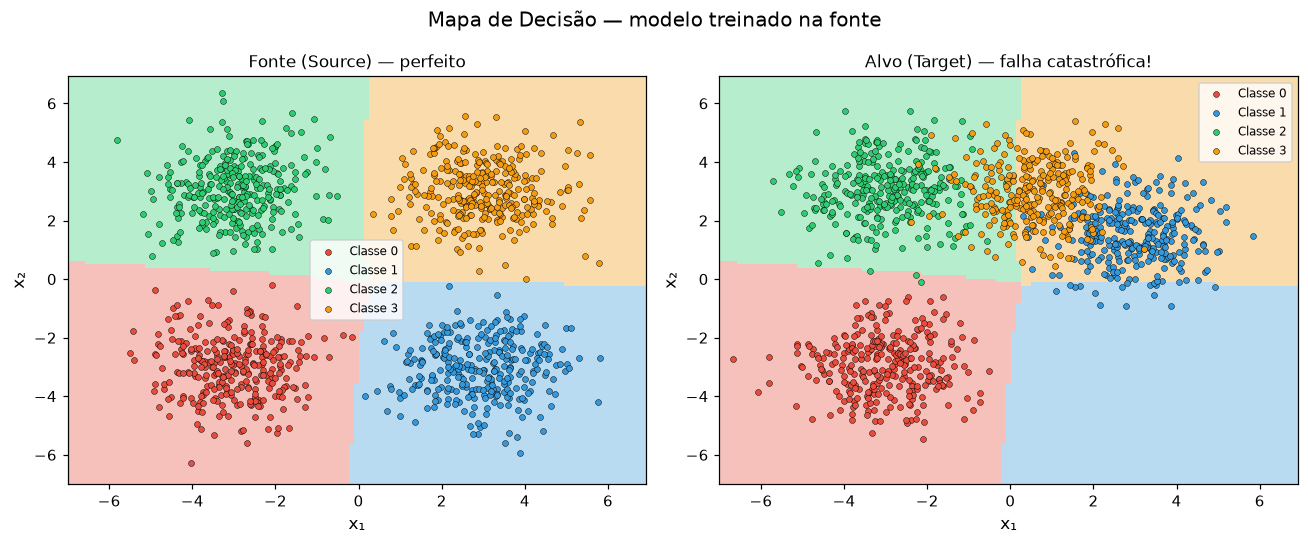

In [8]:
# ── ATO 2.4: Figura-assinatura — mapa de decisão ─────────────────────────────

def criar_malha(xlim=(-7, 7), ylim=(-7, 7), passo=0.12):
    """Cria malha 2D para o mapa de decisão."""
    xx, yy = np.meshgrid(
        np.arange(xlim[0], xlim[1], passo),
        np.arange(ylim[0], ylim[1], passo),
    )
    return xx, yy


def plotar_mapa_decisao(ax, enc_params, head_params,
                        X_overlay, y_overlay, titulo, xx, yy,
                        alpha_fundo=0.35):
    """
    Plota o mapa de decisão (fundo pcolormesh) com pontos sobrepostos.
    """
    # Predições em todos os pontos da malha
    pts    = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds  = predizer_classes(enc_params, head_params, pts)
    Z      = preds.reshape(xx.shape)

    # Fundo: regiões de decisão semitransparentes
    cmap_bg = mcolors.ListedColormap(
        [mcolors.to_rgba(c, alpha_fundo) for c in CORES_CLASSES])
    ax.pcolormesh(xx, yy, Z, cmap=cmap_bg, shading="auto",
                  vmin=0, vmax=N_CLASSES - 1)

    # Pontos sobrepostos
    for c in range(N_CLASSES):
        mask = y_overlay == c
        ax.scatter(X_overlay[mask, 0], X_overlay[mask, 1],
                   s=15, color=CORES_CLASSES[c],
                   edgecolors="k", linewidths=0.3,
                   zorder=3, label=NOMES_CLASSES[c])

    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())


try:
    xx, yy = criar_malha()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Mapa de Decisão — modelo treinado na fonte", fontsize=13)

    plotar_mapa_decisao(ax1, enc_fonte, head_fonte, X_fonte, y_fonte,
                        "Fonte (Source) — perfeito", xx, yy)
    ax1.legend(fontsize=8)

    plotar_mapa_decisao(ax2, enc_fonte, head_fonte, X_alvo, y_alvo,
                        "Alvo (Target) — falha catastrófica!", xx, yy)
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
except Exception:
    print("(Usando imagens pré-geradas)")
    display(Image(str(ASSETS / "nb1_fig_decision_source.png")))
    display(Image(str(ASSETS / "nb1_fig_decision_target.png")))

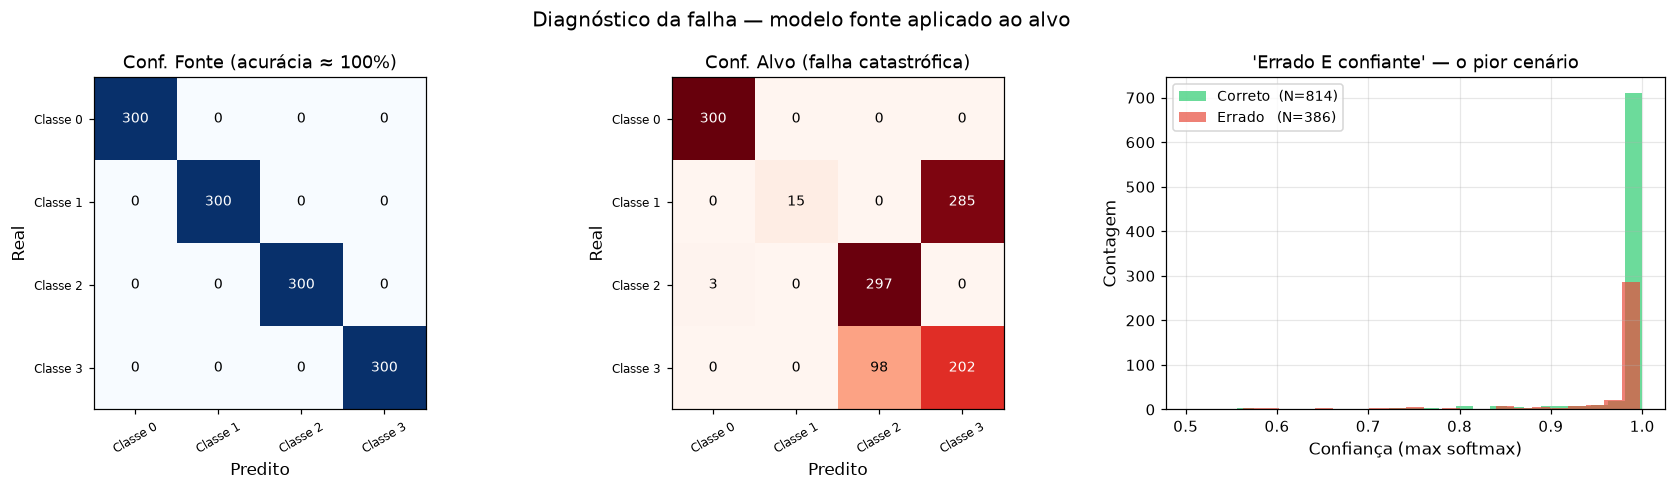


Macro-F1 (zero-shot no alvo): 0.615
Confiança média — predições ERRADAS: 0.953
Confiança média — predições CORRETAS: 0.979


In [9]:
# ── ATO 2.5: Matrizes de confusão e histograma de confiança ──────────────────

# Predições do modelo fonte no domínio alvo
preds_alvo  = predizer_classes(enc_fonte, head_fonte, X_alvo)
logits_alvo = forward_head(head_fonte,
    forward_encoder(enc_fonte, jnp.array(X_alvo, dtype=jnp.float32)))
probs_alvo  = np.array(jax.nn.softmax(logits_alvo, axis=-1))
confianca   = probs_alvo.max(axis=1)    # max softmax = "confiança"
correto     = (preds_alvo == y_alvo)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Diagnóstico da falha — modelo fonte aplicado ao alvo", fontsize=13)

# Matriz de confusão na fonte
cm_fonte = confusion_matrix(y_fonte,
                             predizer_classes(enc_fonte, head_fonte, X_fonte))
axes[0].imshow(cm_fonte, cmap="Blues")
axes[0].set_title("Conf. Fonte (acurácia ≈ 100%)")
axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[0].text(j, i, cm_fonte[i, j], ha="center", va="center",
                     color="white" if cm_fonte[i, j] > cm_fonte.max()*0.5 else "black",
                     fontsize=9)
axes[0].set_xticks(range(N_CLASSES)); axes[0].set_yticks(range(N_CLASSES))
axes[0].set_xticklabels(NOMES_CLASSES, rotation=30, fontsize=8)
axes[0].set_yticklabels(NOMES_CLASSES, fontsize=8)

# Matriz de confusão no alvo
cm_alvo = confusion_matrix(y_alvo, preds_alvo)
axes[1].imshow(cm_alvo, cmap="Reds")
axes[1].set_title("Conf. Alvo (falha catastrófica)")
axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Real")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[1].text(j, i, cm_alvo[i, j], ha="center", va="center",
                     color="white" if cm_alvo[i, j] > cm_alvo.max()*0.5 else "black",
                     fontsize=9)
axes[1].set_xticks(range(N_CLASSES)); axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(NOMES_CLASSES, rotation=30, fontsize=8)
axes[1].set_yticklabels(NOMES_CLASSES, fontsize=8)

# Histograma de confiança: certo vs. errado
axes[2].hist(confianca[correto],  bins=25, alpha=0.7, color="#2ecc71",
             label=f"Correto  (N={correto.sum()})")
axes[2].hist(confianca[~correto], bins=25, alpha=0.7, color="#e74c3c",
             label=f"Errado   (N={(~correto).sum()})")
axes[2].set_xlabel("Confiança (max softmax)")
axes[2].set_ylabel("Contagem")
axes[2].set_title("'Errado E confiante' — o pior cenário")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

f1_zs = f1_score(y_alvo, preds_alvo, average="macro", zero_division=0)
print(f"\nMacro-F1 (zero-shot no alvo): {f1_zs:.3f}")
print(f"Confiança média — predições ERRADAS: "
      f"{confianca[~correto].mean():.3f}")
print(f"Confiança média — predições CORRETAS: "
      f"{confianca[correto].mean():.3f}")

---
## 🟢 ATO 3 — Diagnosticar o Shift Sem Rótulos do Alvo

Aqui está a ideia elegante: **não precisamos de rótulos de classe no alvo**
para saber se o shift existe. Basta treinar um classificador binário que
responde: "Este ponto veio da fonte ou do alvo?"

- Se o classificador binário consegue separar bem (AUC > 0,7), o shift
  é detectável — as distribuições são diferentes.
- Se ele falha (AUC ≈ 0,5), as distribuições são indistinguíveis — não
  há shift relevante.

Este diagnóstico funciona em qualquer dimensão, com qualquer dado, e
sem um único rótulo de classe do alvo.

AUC do classificador de domínio: nan
→ AUC ≈ 0,5: domínios indistinguíveis — sem shift relevante.


/home/dlopez/miniconda3/envs/WinterSchool/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/dlopez/miniconda3/envs/WinterSchool/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


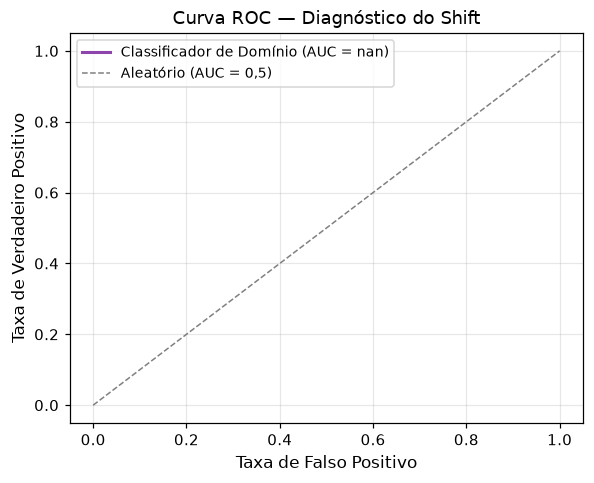

In [10]:
# ── ATO 3.1: Classificador de domínio ────────────────────────────────────────

def treinar_classificador_dominio(X_src, X_tgt, chave, n_epochs=400, lr=3e-3):
    """
    Treina MLP binário [2→16→1] para separar Fonte (y=0) de Alvo (y=1).
    Retorna (params, probabilidades no alvo, AUC).
    """
    # Dados binários: 0 = fonte, 1 = alvo
    X_bin = np.concatenate([X_src, X_tgt]).astype(np.float32)
    y_bin = np.concatenate([np.zeros(len(X_src)), np.ones(len(X_tgt))])
    y_bin = y_bin.astype(np.float32)

    Xj = jnp.array(X_bin)
    yj = jnp.array(y_bin)

    # Inicialização
    chave, ke = jax.random.split(chave)
    params = init_mlp([2, 16, 1], ke)

    def bce_loss(params, X, y):
        """Binary cross-entropy com sigmoid."""
        h = X
        for W, b in params[:-1]:
            h = jnp.tanh(h @ W + b)
        W, b = params[-1]
        logit = (h @ W + b).squeeze(-1)
        return jnp.mean(jax.nn.softplus(logit) - y * logit)

    grad_fn = jax.jit(jax.grad(bce_loss))
    m, v = adam_init(params)

    for t in range(1, n_epochs + 1):
        g  = grad_fn(params, Xj, yj)
        params, m, v = adam_passo(params, g, m, v, t, lr=lr)

    # Probabilidades no alvo
    h = jnp.array(X_tgt, dtype=jnp.float32)
    for W, b in params[:-1]:
        h = jnp.tanh(h @ W + b)
    W, b = params[-1]
    logit_tgt = (h @ W + b).squeeze(-1)
    prob_tgt  = np.array(jax.nn.sigmoid(logit_tgt))
    auc       = roc_auc_score(np.ones(len(X_tgt)), prob_tgt)
    return params, prob_tgt, auc


chave_dom = jax.random.PRNGKey(7)
_, prob_dom, auc_dom = treinar_classificador_dominio(
    X_fonte, X_alvo, chave_dom)

print(f"AUC do classificador de domínio: {auc_dom:.3f}")
if auc_dom > 0.7:
    print("→ AUC > 0,7: shift detectável — os domínios são separáveis!")
else:
    print("→ AUC ≈ 0,5: domínios indistinguíveis — sem shift relevante.")

# Curva ROC
fpr, tpr, _ = roc_curve(np.ones(len(X_alvo)), prob_dom)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr, tpr, lw=2, color="#8e44ad",
        label=f"Classificador de Domínio (AUC = {auc_dom:.2f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Aleatório (AUC = 0,5)")
ax.set_xlabel("Taxa de Falso Positivo")
ax.set_ylabel("Taxa de Verdadeiro Positivo")
ax.set_title("Curva ROC — Diagnóstico do Shift")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

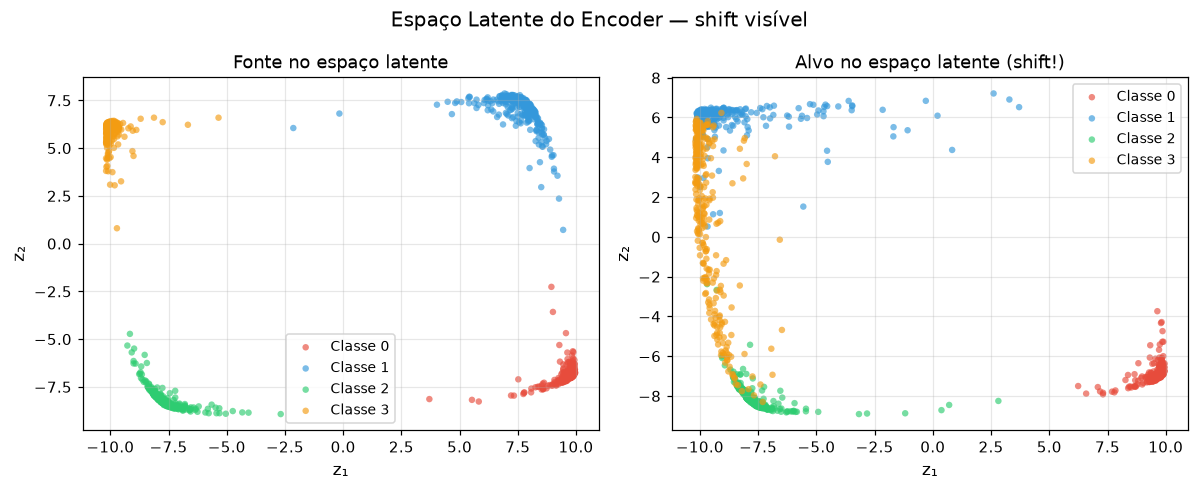

In [11]:
# ── ATO 3.2: Scatter latente — shift visível no espaço latente ───────────────

try:
    Z_fonte = obter_embeddings(enc_fonte, X_fonte)
    Z_alvo  = obter_embeddings(enc_fonte, X_alvo)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.suptitle("Espaço Latente do Encoder — shift visível", fontsize=13)

    for c in range(N_CLASSES):
        ax1.scatter(Z_fonte[y_fonte==c, 0], Z_fonte[y_fonte==c, 1],
                    s=18, color=CORES_CLASSES[c], alpha=0.65,
                    edgecolors="none", label=NOMES_CLASSES[c])
    ax1.set_title("Fonte no espaço latente")
    ax1.set_xlabel("z₁"); ax1.set_ylabel("z₂")
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

    for c in range(N_CLASSES):
        ax2.scatter(Z_alvo[y_alvo==c, 0], Z_alvo[y_alvo==c, 1],
                    s=18, color=CORES_CLASSES[c], alpha=0.65,
                    edgecolors="none", label=NOMES_CLASSES[c])
    ax2.set_title("Alvo no espaço latente (shift!)")
    ax2.set_xlabel("z₁"); ax2.set_ylabel("z₂")
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
except Exception:
    display(Image(str(ASSETS / "nb1_fig_latent_shift.png")))

---
## 🟢 ATO 4 — Os Três Regimes de Adaptação

Temos K rótulos do domínio alvo disponíveis. O que fazemos com eles?

| Regime | Descrição | Quando usar? |
|--------|-----------|-------------|
| **(A) Zero-shot** | Aplica o modelo fonte diretamente — sem adaptar nada | Baseline; K=0 |
| **(B) Somente alvo** | Treina encoder + cabeça do zero nos K exemplos do alvo | Quando não há pré-treino ou shift é severo |
| **(C) SSDA** | Carrega encoder pré-treinado, **congela a cabeça**, adapta só o encoder com K exemplos | Baixo K; pré-treino rico |

**SSDA = Semi-Supervised Domain Adaptation.**

O parâmetro K controla o trade-off: para K pequeno, o pré-treino do SSDA
é muito valioso. Para K grande, o regime (B) pode superar o (C) porque
o encoder tem liberdade de se especializar no alvo.

In [12]:
# ── ATO 4.1: Regime (A) — Zero-shot (já pronto) ──────────────────────────────
# O modelo fonte é o regime A. Já calculamos o Macro-F1 acima.

print("=== Regime (A): Zero-shot ===")
preds_A = predizer_classes(enc_fonte, head_fonte, X_alvo)
f1_A    = f1_score(y_alvo, preds_A, average="macro", zero_division=0)
print(f"  Macro-F1 no alvo: {f1_A:.3f}")

=== Regime (A): Zero-shot ===
  Macro-F1 no alvo: 0.615


In [13]:
# ── ATO 4.2: Regime (B) — Target-only com K=50 ───────────────────────────────

K = 50   # número de rótulos do alvo disponíveis


def amostrar_k_rotulos(X, y, K, chave, n_classes=N_CLASSES):
    """Amostragem estratificada: K total, distribuídos entre as classes."""
    k_por_classe = max(1, K // n_classes)
    idx_list = []
    for c in range(n_classes):
        idx_c  = np.where(y == c)[0]
        chave, k = jax.random.split(chave)
        escolhidos = jax.random.permutation(k, len(idx_c))[:k_por_classe]
        idx_list.append(idx_c[np.array(escolhidos)])
    return X[np.concatenate(idx_list)], y[np.concatenate(idx_list)]


if not PRETRAINED:
    print(f"=== Regime (B): Target-only (K={K}) — treinando do zero... ===")
    chave_k = jax.random.PRNGKey(1)
    X_k, y_k = amostrar_k_rotulos(X_alvo, y_alvo, K, chave_k)

    chave_b = jax.random.PRNGKey(2)
    chave_b, ke, kh = jax.random.split(chave_b, 3)
    enc_to   = init_mlp([2, 32, 32, 2], ke)
    head_to  = init_mlp([2, N_CLASSES], kh)

    Xk_j = jnp.array(X_k, dtype=jnp.float32)
    yk_j = jnp.array(y_k, dtype=jnp.int32)

    grad_fn_b = jax.jit(jax.grad(perda_ce_ponderada, argnums=(0, 1)))
    m_e, v_e = adam_init(enc_to)
    m_h, v_h = adam_init(head_to)

    for t in range(1, 601):
        g_e, g_h = grad_fn_b(enc_to, head_to, Xk_j, yk_j, pesos_jnp)
        enc_to,  m_e, v_e = adam_passo(enc_to,  g_e, m_e, v_e, t)
        head_to, m_h, v_h = adam_passo(head_to, g_h, m_h, v_h, t)
    print("  Treino concluído.")
else:
    enc_to  = pickle.load(open(ASSETS / "nb1_encoder_targetonly.pkl", "rb"))
    head_to = pickle.load(open(ASSETS / "nb1_head_targetonly.pkl",    "rb"))
    print(f"=== Regime (B): Target-only (K={K}) — checkpoint carregado. ===")

preds_B = predizer_classes(enc_to, head_to, X_alvo)
f1_B    = f1_score(y_alvo, preds_B, average="macro", zero_division=0)
print(f"  Macro-F1 no alvo: {f1_B:.3f}")

=== Regime (B): Target-only (K=50) — checkpoint carregado. ===
  Macro-F1 no alvo: 0.853


In [14]:
# ── ATO 4.3: Regime (C) — SSDA (encoder adaptado, cabeça congelada) ──────────

# Como congelamos a cabeça?
# Usamos jax.grad(..., argnums=0) — gradiente APENAS em relação ao primeiro
# argumento (enc_params). O head_params não recebe gradiente.

def perda_ce_so_encoder(enc_params, head_params_congelado, X, y, pesos):
    """CE loss diferenciável apenas em enc_params."""
    return perda_ce_ponderada(enc_params, head_params_congelado, X, y, pesos)


if not PRETRAINED:
    print(f"=== Regime (C): SSDA (K={K}) — adaptando encoder... ===")
    # Reutiliza os K mesmos exemplos do regime B
    enc_ssda  = enc_fonte   # parte do encoder pré-treinado na fonte
    head_ssda = head_fonte  # cabeça CONGELADA (vocabulário fixo)

    grad_fn_c = jax.jit(jax.grad(perda_ce_so_encoder, argnums=0))
    m_e2, v_e2 = adam_init(enc_ssda)

    for t in range(1, 601):
        g_e = grad_fn_c(enc_ssda, head_ssda, Xk_j, yk_j, pesos_jnp)
        enc_ssda, m_e2, v_e2 = adam_passo(enc_ssda, g_e, m_e2, v_e2, t)
    print("  Adaptação concluída.")
else:
    enc_ssda  = pickle.load(open(ASSETS / "nb1_encoder_ssda.pkl",  "rb"))
    head_ssda = pickle.load(open(ASSETS / "nb1_head_ssda.pkl",     "rb"))
    print(f"=== Regime (C): SSDA (K={K}) — checkpoint carregado. ===")

preds_C = predizer_classes(enc_ssda, head_ssda, X_alvo)
f1_C    = f1_score(y_alvo, preds_C, average="macro", zero_division=0)
print(f"  Macro-F1 no alvo: {f1_C:.3f}")

# Resumo
print("\n── Resumo dos 3 regimes (Macro-F1 no alvo) ──────────────────────────")
print(f"  (A) Zero-shot    : {f1_A:.3f}")
print(f"  (B) Somente alvo : {f1_B:.3f}")
print(f"  (C) SSDA         : {f1_C:.3f}")

=== Regime (C): SSDA (K=50) — checkpoint carregado. ===
  Macro-F1 no alvo: 0.854

── Resumo dos 3 regimes (Macro-F1 no alvo) ──────────────────────────
  (A) Zero-shot    : 0.615
  (B) Somente alvo : 0.853
  (C) SSDA         : 0.854


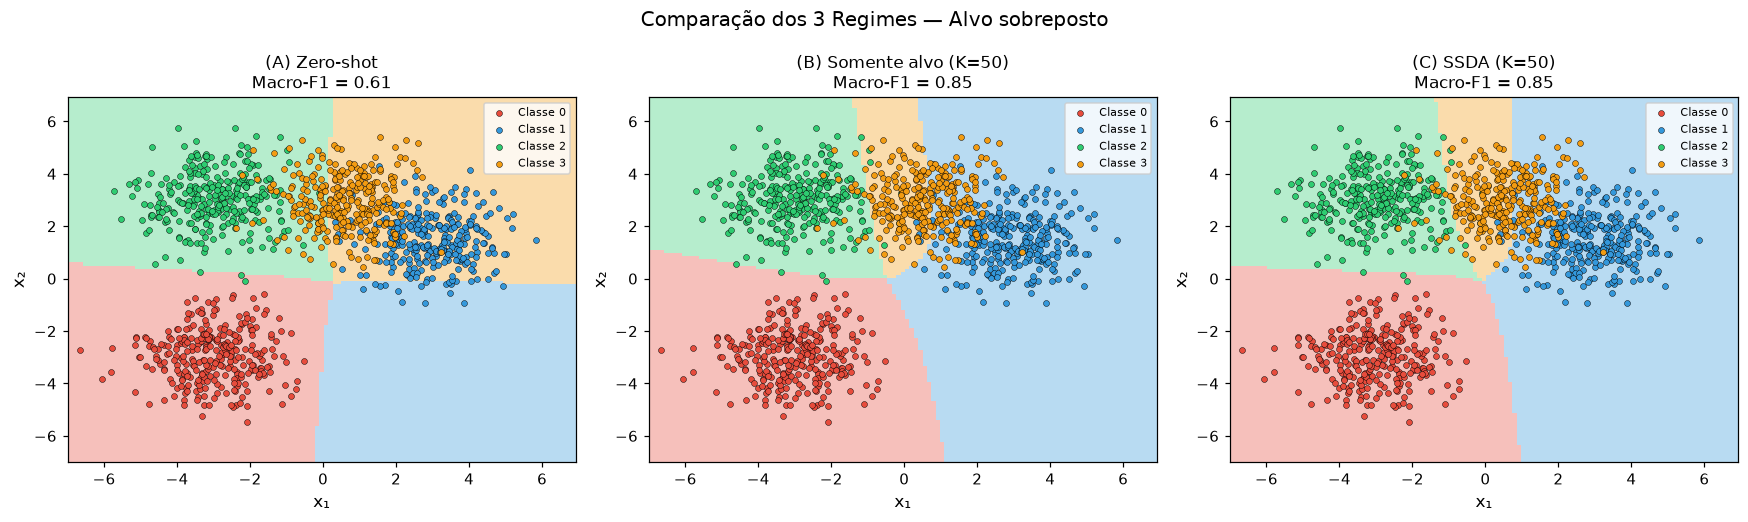

In [15]:
# ── ATO 4.4: Comparação — 3 mapas de decisão lado a lado ─────────────────────

try:
    xx, yy = criar_malha()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    fig.suptitle("Comparação dos 3 Regimes — Alvo sobreposto", fontsize=13)

    regimes = [
        (f"(A) Zero-shot\nMacro-F1 = {f1_A:.2f}", enc_fonte, head_fonte),
        (f"(B) Somente alvo (K={K})\nMacro-F1 = {f1_B:.2f}", enc_to,   head_to),
        (f"(C) SSDA (K={K})\nMacro-F1 = {f1_C:.2f}",          enc_ssda, head_ssda),
    ]
    for ax, (titulo, enc_, head_) in zip(axes, regimes):
        plotar_mapa_decisao(ax, enc_, head_, X_alvo, y_alvo, titulo, xx, yy)
        ax.legend(fontsize=7, loc="upper right")

    plt.tight_layout(); plt.show()
except Exception:
    display(Image(str(ASSETS / "nb1_fig_comparison.png")))

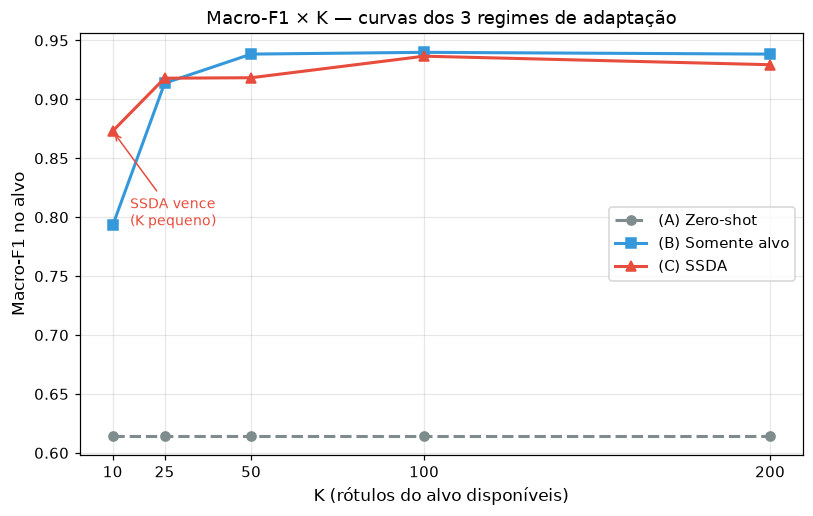

Valores do K-sweep:
    K   Zero-shot   Somente alvo    SSDA
   10       0.615          0.793   0.873
   25       0.615          0.914   0.918
   50       0.615          0.938   0.918
  100       0.615          0.940   0.937
  200       0.615          0.938   0.929


In [16]:
# ── ATO 4.5: Figura-síntese — Macro-F1 × K ───────────────────────────────────
# A varredura em K é pré-computada (muito lenta para executar ao vivo).

try:
    ksweep = np.load(ASSETS / "nb1_ksweep.npz")
    K_vals = ksweep["K_values"]
    f1_zs  = ksweep["f1_zeroshot"]
    f1_to  = ksweep["f1_targetonly"]
    f1_ss  = ksweep["f1_ssda"]

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(K_vals, f1_zs, "o--", color="#7f8c8d", lw=2,
            label="(A) Zero-shot")
    ax.plot(K_vals, f1_to, "s-",  color="#3498db", lw=2,
            label="(B) Somente alvo")
    ax.plot(K_vals, f1_ss, "^-",  color="#e74c3c", lw=2,
            label="(C) SSDA")
    ax.set_xlabel("K (rótulos do alvo disponíveis)")
    ax.set_ylabel("Macro-F1 no alvo")
    ax.set_title("Macro-F1 × K — curvas dos 3 regimes de adaptação")
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    ax.set_xticks(K_vals)

    # Anotar a região onde SSDA vence
    ax.annotate("SSDA vence\n(K pequeno)",
                xy=(K_vals[0], f1_ss[0]), xytext=(K_vals[0]+5, f1_ss[0]-0.08),
                fontsize=9, color="#e74c3c",
                arrowprops=dict(arrowstyle="->", color="#e74c3c"))

    plt.tight_layout(); plt.show()

    print("Valores do K-sweep:")
    print(f"{'K':>5}  {'Zero-shot':>10}  {'Somente alvo':>13}  {'SSDA':>6}")
    for i, k in enumerate(K_vals):
        print(f"{k:5d}  {f1_zs[i]:10.3f}  {f1_to[i]:13.3f}  {f1_ss[i]:6.3f}")
except Exception:
    display(Image(str(ASSETS / "nb1_fig_k_sweep.png")))

## 🟡 Poll — Ato 4

**Por que congelamos a CABEÇA e não o encoder?**

*(Dica: pense em alguém que muda de país mas fala o mesmo idioma.)*

**Levante a mão** com sua hipótese antes de ler a célula seguinte.

## 🟢 Resposta ao Poll

A resposta está na separação de papéis entre encoder e cabeça:

- **A cabeça** aprendeu **conceitos**: "o que é a Classe 0 no espaço
  latente", "onde fica a Classe 3", etc. Este vocabulário foi aprendido
  com muitos dados da fonte e é conceitualmente correto — não queremos
  desaprender isso com apenas K exemplos.

- **O encoder** aprendeu **percepção**: como mapear dados brutos para
  o espaço latente. Este mapeamento está calibrado para a fonte.
  Adaptar o encoder = recalibrar a percepção para o novo domínio,
  sem mudar os conceitos.

Analogia: **adaptar ao sotaque, não reaprender o idioma.**
Se você fala português do Brasil e vai para Portugal, não precisa
reaprender o vocabulário — basta calibrar o ouvido para o novo sotaque.

Em física: é como recalibrar um detector para um novo ambiente sem
reescrever o manual de análise dos dados.

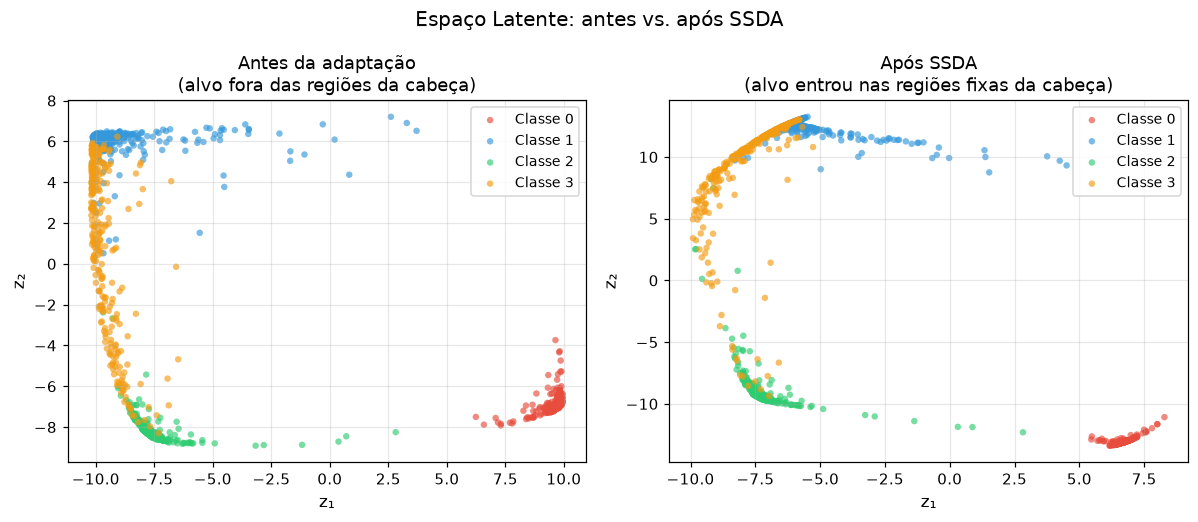

In [17]:
# ── ATO 4.6: Latente pós-SSDA — alvo entrou nas regiões da cabeça ────────────

try:
    Z_antes = obter_embeddings(enc_fonte, X_alvo)
    Z_depois = obter_embeddings(enc_ssda, X_alvo)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8))
    fig.suptitle("Espaço Latente: antes vs. após SSDA", fontsize=13)

    for c in range(N_CLASSES):
        ax1.scatter(Z_antes[y_alvo==c, 0], Z_antes[y_alvo==c, 1],
                    s=18, color=CORES_CLASSES[c], alpha=0.65,
                    edgecolors="none", label=NOMES_CLASSES[c])
    ax1.set_title("Antes da adaptação\n(alvo fora das regiões da cabeça)")
    ax1.set_xlabel("z₁"); ax1.set_ylabel("z₂")
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

    for c in range(N_CLASSES):
        ax2.scatter(Z_depois[y_alvo==c, 0], Z_depois[y_alvo==c, 1],
                    s=18, color=CORES_CLASSES[c], alpha=0.65,
                    edgecolors="none", label=NOMES_CLASSES[c])
    ax2.set_title("Após SSDA\n(alvo entrou nas regiões fixas da cabeça)")
    ax2.set_xlabel("z₁"); ax2.set_ylabel("z₂")
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
except Exception:
    display(Image(str(ASSETS / "nb1_fig_latent_ssda.png")))

## 🟢 Takeaway

> **"Quebrar é fácil, falhar em silêncio é perigoso, adaptar é barato —
> se você souber o que congelar."**

Resumo do que aprendemos hoje:

1. **Domain shift** acontece quando a distribuição dos dados muda entre
   treino (fonte) e inferência (alvo). O modelo fica confiante — e errado.

2. **Diagnóstico sem rótulos**: um classificador de domínio detecta shift
   com AUC > 0,7 sem precisar de nenhum rótulo de classe do alvo.

3. **SSDA vence para K pequeno**: se você tem poucos rótulos do alvo,
   o pré-treino na fonte é um ativo valioso. Congele a cabeça (os conceitos)
   e adapte só o encoder (a percepção).

**Sexta-feira:** este experimento exato, com espectros de quasares reais
do telescópio J-PAS, com 56 bandas fotométricas e dezenas de milhares de
objetos. O que hoje foi 2D, será 56D.

---
## 🟣 Para quem quer mais — Extensões Opcionais

> O instrutor dirá: "Vocês não precisam fazer agora."
> Estas células estão aqui para quem quiser explorar depois.

In [18]:
# 🟣 (Opcional) Mapas de probabilidade por classe ─────────────────────────────
# Mostra P(classe=k | x) como mapa de calor para cada uma das 4 classes.

if False:   # mude para True para executar
    xx_p, yy_p = criar_malha(passo=0.15)
    pts_p = np.c_[xx_p.ravel(), yy_p.ravel()].astype(np.float32)
    logits_p = forward_head(head_ssda,
        forward_encoder(enc_ssda, jnp.array(pts_p)))
    probs_p = np.array(jax.nn.softmax(logits_p, axis=-1))

    fig, axes = plt.subplots(1, N_CLASSES, figsize=(16, 4))
    fig.suptitle("Mapas de Probabilidade por Classe (modelo SSDA)", fontsize=13)

    for c in range(N_CLASSES):
        P_c = probs_p[:, c].reshape(xx_p.shape)
        im  = axes[c].pcolormesh(xx_p, yy_p, P_c,
                                  cmap="viridis", shading="auto",
                                  vmin=0, vmax=1)
        axes[c].set_title(NOMES_CLASSES[c])
        axes[c].set_xlabel("x₁")
        if c == 0:
            axes[c].set_ylabel("x₂")
        plt.colorbar(im, ax=axes[c], fraction=0.046)

    plt.tight_layout()
    plt.show()

In [19]:
# 🟣 (Opcional) Shift de prior (não de posição) ───────────────────────────────
# Gera dados onde as frequências de classe mudam entre domínios,
# mas as posições das nuvens são idênticas. Repete os 4 atos.

if False:   # mude para True para executar
    # Frequências: fonte [50,25,15,10] → alvo [10,15,25,50] (invertidas)
    pesos_alvo_prior = np.array([0.10, 0.15, 0.25, 0.50], dtype=np.float32)

    # Gera dados com as mesmas posições mas frequências diferentes no alvo
    chave_prior = jax.random.PRNGKey(77)
    n_total = N_POR_CLASSE * N_CLASSES
    X_ap_list, y_ap_list = [], []
    for c in range(N_CLASSES):
        chave_prior, kc = jax.random.split(chave_prior)
        n_c = int(n_total * pesos_alvo_prior[c])
        pts = jax.random.normal(kc, (n_c, 2)) + MEDIAS_FONTE[c]
        X_ap_list.append(np.array(pts))
        y_ap_list.append(np.full(n_c, c, dtype=np.int32))

    X_alvo_prior = np.concatenate(X_ap_list)
    y_alvo_prior = np.concatenate(y_ap_list)

    preds_prior = predizer_classes(enc_fonte, head_fonte, X_alvo_prior)
    f1_prior    = f1_score(y_alvo_prior, preds_prior, average="macro",
                           zero_division=0)
    print(f"Prior shift — Macro-F1 (zero-shot): {f1_prior:.3f}")
    print("(Dica: compara com o shift covariate acima.)")

In [20]:
# 🟣 (Opcional) Espiada no latente com t-SNE ──────────────────────────────────
# Gancho para amanhã: t-SNE é uma ferramenta de inspeção de embeddings.
# Amanhã veremos por quê — e quando ela mente.

if False:   # mude para True para executar
    from sklearn.manifold import TSNE

    # Embeddings 2D do encoder (já estão em 2D, então t-SNE é apenas exemplar)
    Z_all = obter_embeddings(enc_ssda, np.concatenate([X_fonte, X_alvo]))
    y_all = np.concatenate([y_fonte, y_alvo])
    dom_all = np.concatenate([np.zeros(len(y_fonte)), np.ones(len(y_alvo))])

    # t-SNE com 2 perplexidades para mostrar sensibilidade
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, perp in zip(axes, [5, 50]):
        tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
        Z_tsne = tsne.fit_transform(Z_all)
        for c in range(N_CLASSES):
            mask = y_all == c
            ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                       s=10, color=CORES_CLASSES[c], alpha=0.6,
                       label=NOMES_CLASSES[c])
        ax.set_title(f"t-SNE (perplexidade={perp})")
        ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
        ax.legend(fontsize=8)

    fig.suptitle("t-SNE do latente SSDA — gancho para amanhã", fontsize=12)
    plt.tight_layout()
    plt.show()

---
## 🟡 Para Casa

Três exercícios para explorar depois da aula:

**Exercício 1 — Magnitude do shift**
No script de assets (`make_assets_01_domain_shift_toy.py`), altere
`MEDIAS_ALVO` para deslocar as nuvens por 1σ em vez de 2,5σ.
Regenere os assets e observe: como muda a curva Macro-F1 × K?
Para qual magnitude o zero-shot começa a ser competitivo com o SSDA?

**Exercício 2 — Orçamento de rótulos**
Na varredura de K (ATO 4.5), para qual valor de K o regime (B) supera
definitivamente o regime (C)? O que isso diz sobre o custo de rotulação
em projetos reais? Estime: se cada rótulo custa R$ 10 (telescópio-hora),
qual é o orçamento mínimo para abrir mão do pré-treino?

**Exercício 3 — 🟣 Prior shift**
Execute a célula opcional de "shift de prior" (ATO 4, célula 🟣).
Compare o Macro-F1 do zero-shot no prior shift vs. no covariate shift
que vimos na aula. Por que o prior shift é mais "benevolente" com o
classificador fonte? (Dica: as regiões de decisão não mudaram.)